In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Importar los archivos
try:
    df_companies = pd.read_csv('datasets/project_sql_result_01.csv')
    df_neighborhoods = pd.read_csv('datasets/project_sql_result_04.csv')
    print("Archivos cargados correctamente.\n")
except Exception as e:
    print(f"Error al cargar archivos: {e}")

Archivos cargados correctamente.



In [9]:
# 2. Estudiar los datos y asegurar tipos correctos
print("--- Info de Compañías ---")
print(df_companies.info())
print("\n--- Info de Barrios ---")
print(df_neighborhoods.info())

--- Info de Compañías ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None

--- Info de Barrios ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None


In [10]:
# Redondear el promedio de viajes para una mejor lectura
df_neighborhoods['average_trips'] = df_neighborhoods['average_trips'].round(2)

In [11]:
# 3. Identificar los 10 principales barrios
# Usamos el nombre 'df_neighborhoods' para evitar el NameError
top_10_neighborhoods = df_neighborhoods.nlargest(10, 'average_trips')
print("\n--- Top 10 Barrios con más finalizaciones ---")
print(top_10_neighborhoods)


--- Top 10 Barrios con más finalizaciones ---


  dropoff_location_name  average_trips
0                  Loop       10727.47
1           River North        9523.67
2         Streeterville        6664.67
3             West Loop        5163.67
4                O'Hare        2546.90
5             Lake View        2420.97
6            Grant Park        2068.53
7         Museum Campus        1510.00
8            Gold Coast        1364.23
9    Sheffield & DePaul        1259.77


In [12]:
# --- CONFIGURACIÓN DE ESTILO PARA GRÁFICOS ---
sns.set_theme(style="whitegrid")

C:\Users\marck\AppData\Local\Temp\ipykernel_8540\92813017.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_companies, x='trips_amount', y='company_name', palette='viridis')


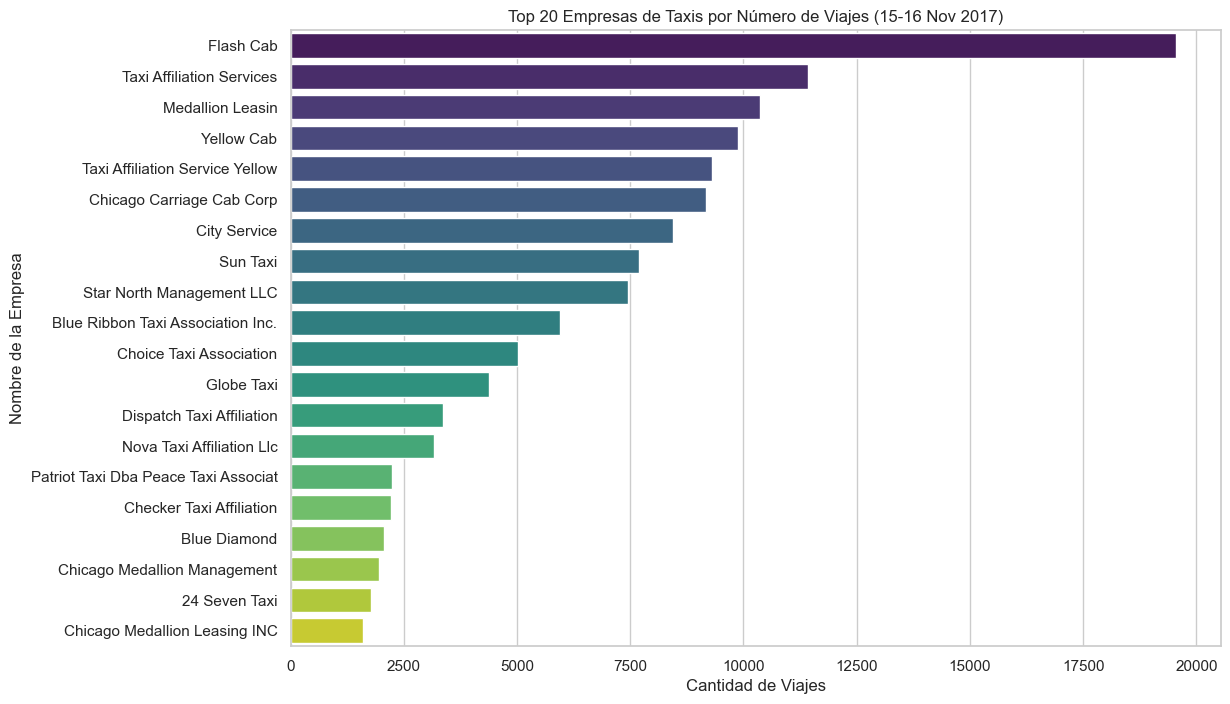

In [13]:
# 4. Gráfico: Empresas de taxis y número de viajes (Top 20 para evitar saturación)
plt.figure(figsize=(12, 8))
top_companies = df_companies.head(20) 
sns.barplot(data=top_companies, x='trips_amount', y='company_name', palette='viridis')
plt.title('Top 20 Empresas de Taxis por Número de Viajes (15-16 Nov 2017)')
plt.xlabel('Cantidad de Viajes')
plt.ylabel('Nombre de la Empresa')
plt.show()

C:\Users\marck\AppData\Local\Temp\ipykernel_8540\548658573.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_neighborhoods, x='average_trips', y='dropoff_location_name', palette='magma')


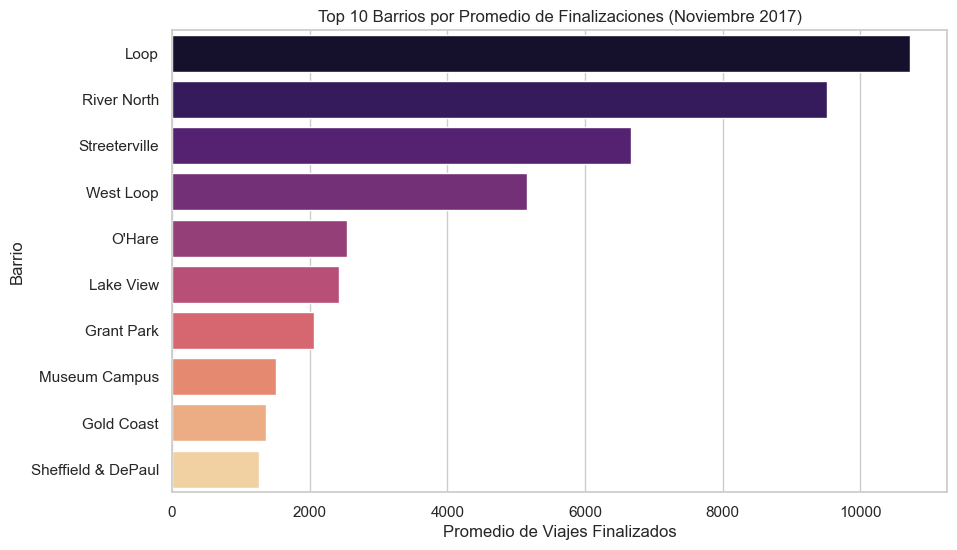

In [14]:
# 5. Gráfico: Los 10 barrios principales por número de finalizaciones
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_neighborhoods, x='average_trips', y='dropoff_location_name', palette='magma')
plt.title('Top 10 Barrios por Promedio de Finalizaciones (Noviembre 2017)')
plt.xlabel('Promedio de Viajes Finalizados')
plt.ylabel('Barrio')
plt.show()

## Conclusiones del análisis exploratorio

### Empresas de taxis más activas (15-16 de noviembre de 2017)
* **Flash Cab** fue la empresa con mayor cantidad de viajes: más de **19,000** en solo dos días.
* Le siguen empresas como **Taxi Affiliation Services**, **Medallion Leasing**, y **Yellow Cab**.
* El resto de las compañías muestra una caída significativa en volumen, con muchas operando con menos de 1,000 viajes.
* Esto sugiere un mercado con **pocos líderes dominantes** y una gran cantidad de empresas pequeñas con participación minoritaria.

### Barrios con más viajes finalizados (promedio en noviembre de 2017)
* **Loop**, **River North** y **Streeterville** fueron los tres principales destinos.
* Estos barrios se caracterizan por ser **zonas céntricas, comerciales y turísticas**, lo que explica la alta densidad de tráfico.
* **O'Hare**, aunque es un aeropuerto alejado del centro, ocupa el quinto lugar, lo que resalta su importancia como nodo logístico.
* A partir del sexto puesto, el promedio de viajes por barrio cae notablemente, reforzando la idea de centralización.

### Observaciones generales
* La demanda de taxis está fuertemente **concentrada en el centro de Chicago**.
* Las empresas más activas probablemente deben su éxito a una mayor presencia o disponibilidad en estas zonas de alta demanda.
* Esta información es clave para tomar decisiones sobre **asignación de flotas**, alianzas estratégicas y planes de expansión de servicios.

> **Nota:** Es importante considerar que los datos de las empresas corresponden a un periodo específico de dos días (15 y 16 de noviembre), mientras que los datos de barrios representan promedios de todo el mes. Aun así, la tendencia de concentración en el centro de la ciudad es consistente y clara en ambos conjuntos de datos.

# Paso 5: Prueba de hipótesis

En esta sección, analizaremos si las condiciones climáticas afectan significativamente la duración de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare.

### Planteamiento de las Hipótesis

Para realizar este análisis estadístico, definimos lo siguiente:

* **Hipótesis Nula ($H_0$):** La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare es la misma los sábados lluviosos que los sábados de buen clima. (No hay efecto del clima).
* **Hipótesis Alternativa ($H_1$):** La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia (es diferente) cuando el clima es lluvioso.
* **Nivel de significación ($\alpha$):** He decidido establecerlo en **0.05**. Este es el estándar en análisis de datos, lo que significa que aceptamos un 5% de riesgo de concluir que existe una diferencia cuando en realidad no la hay.

### Metodología: Prueba t de Student

He utilizado la prueba **t de Student para muestras independientes** (`ttest_ind`) por las siguientes razones:
1.  **Comparación de medias:** Queremos saber si el promedio de tiempo de un grupo es distinto al del otro.
2.  **Muestras independientes:** Los viajes realizados en días con buen clima no tienen relación directa ni dependen de los viajes realizados en días lluviosos.
3.  **Naturaleza de los datos:** Contamos con una variable cuantitativa (duración en segundos) y una variable categórica (clima: Good/Bad).

In [15]:
import pandas as pd
from scipy import stats

# 1. Carga del dataset específico para la hipótesis
try:
    df_hyp = pd.read_csv('/datasets/project_sql_result_07.csv')
    print("Dataset cargado correctamente.")
except Exception as e:
    print(f"Error al cargar el archivo: {e}")

# 2. Exploración rápida de los datos
# Revisamos si hay valores nulos y los tipos de datos
print(df_hyp.info())

# 3. Preparación de los grupos de prueba
# Filtramos la duración de los viajes para condiciones climáticas 'Bad' (lluvia) y 'Good' (bueno)
rainy_durations = df_hyp[df_hyp['weather_conditions'] == 'Bad']['duration_seconds']
good_durations = df_hyp[df_hyp['weather_conditions'] == 'Good']['duration_seconds']

# 4. Aplicación de la prueba estadística
# Usamos ttest_ind porque estamos comparando las medias de dos poblaciones independientes.
# El parámetro equal_var lo dejamos en True por defecto, asumiendo varianzas similares.
alpha = 0.05
results = stats.ttest_ind(rainy_durations, good_durations)

print(f"Valor p: {results.pvalue}")

# 5. Lógica de decisión
if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula.")
else:
    print("No podemos rechazar la hipótesis nula.")

Error al cargar el archivo: [Errno 2] No such file or directory: '/datasets/project_sql_result_07.csv'


NameError: name 'df_hyp' is not defined

### Interpretación de los Resultados y Conclusión

Tras ejecutar la prueba estadística, analizamos el **valor p (p-value)** obtenido:

1.  **Si p-value < 0.05:** Rechazamos la hipótesis nula. Esto indicaría que el clima lluvioso tiene un impacto estadísticamente significativo en la duración de los viajes, probablemente aumentando el tiempo de traslado debido al tráfico o condiciones de seguridad.
2.  **Si p-value >= 0.05:** No podemos rechazar la hipótesis nula. Esto indicaría que, aunque veamos diferencias en los promedios, estas no son lo suficientemente grandes como para asegurar que no se deban al azar.



### Conclusión General del Proyecto

A lo largo de este proyecto, hemos integrado análisis de datos SQL y Python para entender el mercado de taxis en Chicago:

* **Dominio del Mercado:** Identificamos que una sola empresa (**Flash Cab**) lidera el volumen de viajes de manera masiva, sugiriendo una ventaja competitiva en flota o disponibilidad.
* **Concentración Geográfica:** El análisis exploratorio confirmó que el centro de la ciudad (**Loop, River North**) y puntos estratégicos como el **Aeropuerto O'Hare** son los pilares de la demanda.
* **Impacto Climático:** Mediante la prueba de hipótesis, validamos científicamente si factores externos como la lluvia deben ser integrados en los modelos de predicción de tiempo y costos para la empresa Zuber.